# <span style='color:Red'>Data preprocessing</span>

## <span style='color:Red'>Libraries, functions, paths</span>

In [1]:
import sys, os
from pathlib import Path

currentWD = os.path.dirname(Path.cwd())
if currentWD not in sys.path:
    sys.path.append(currentWD)
#print(sys.path)

import numpy, os, pandas, re, ast, seaborn, jlib
from matplotlib import pyplot
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

saveFigs = True
imagePath = 'img/bias/'
imageFormats = ['svg','pdf']
exportsPath = 'exports/'

minAccuracyValue = 0
maxAccuracyValue = 1.2

minBiasValue = -8
maxBiasValue = 18

minErrorDistanceValue = -10
maxErrorDistanceValue = 10

minSlopeValue = -1
maxSlopeValue = 1

significanceSize = 14

desiredEffectSize = 'ges'

paletteBase = {'Chunkable':'#a1c9f4','Non-chunkable':'#ffb482'}
paletteInformative = {'Chunkable':'#7ca3cc','Non-chunkable':'#d68e5d'}
paletteUninformative = {'Chunkable':'#c7f0ff','Non-chunkable':'#ffdba8'}
paletteIUCombined = {'Chunkable\nInformative':"#7ca3cc",'Non-chunkable\nInformative':"#d68e5d",
                     'Chunkable\nUninformative':"#c7f0ff",'Non-chunkable\nUninformative':"#ffdba8"}

if not os.path.exists(imagePath):
    os.makedirs(imagePath)

mapValueHandler = jlib.data.mapValueHandler.MapValueHandler(exportsPath+"exp4Values.csv")

allParticipantData = pandas.read_csv(exportsPath+'participantData_long.csv')
allParticipantData.drop(['Mouse X path','Mouse Y path',],axis=1,inplace=True)

## <span style='color:Red'>Bias (chunkable vs non-chunkabe)</span>

In [2]:
columnsToKeep = ['Subject','Trial type','Response error','Flipped error','Cue type']

copyData = allParticipantData.copy()
copyData.drop([column for column in copyData.columns if column not in columnsToKeep],axis=1,inplace=True)

angleColumns = [column for column in copyData.columns if column not in ['Subject','Trial type','Cue type']]
meanData = copyData.groupby(['Subject','Trial type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
meanData

,Subject,Trial type,Response error,Flipped error
0,400,Chunkable,-0.012848,9.582141
1,400,Non-chunkable,-1.866261,7.209357
2,401,Chunkable,-2.417229,4.680407
3,401,Non-chunkable,-0.892319,0.680734
4,403,Chunkable,-0.851538,-0.050258
5,403,Non-chunkable,-4.269318,-2.217090
6,404,Chunkable,6.300618,3.559154
7,404,Non-chunkable,1.955412,7.187571
8,405,Chunkable,0.668609,5.810904
9,405,Non-chunkable,1.265159,-6.749253


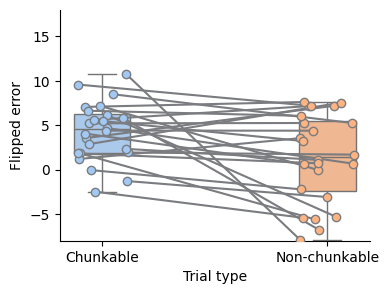

In [3]:
fig,ax = pyplot.subplots(figsize=(4,3))
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=meanData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
ax.set_ylim(minBiasValue,maxBiasValue)
seaborn.despine()

In [4]:
meanNCTrialData = meanData[meanData['Trial type']=='Non-chunkable']['Flipped error'].to_numpy()
meanCTrialData = meanData[meanData['Trial type']=='Chunkable']['Flipped error'].to_numpy()

baseBiasTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       column1=meanCTrialData,
                                                       column2=meanNCTrialData,
                                                       isStudent=False,isWilcoxon=True,hypothesis='different',
                                                       effectSize=True,descriptives=True)

baseBiasTtestPS['ttest'].columns = baseBiasTtestPS['ttest'].columns.str.rstrip('[wilc]')

# mapValueHandler.setKeyValue("ttestPSBiasAllTrialsChunkingEffect",
#                             jlib.data.constants.extractWilcoxonResults(baseBiasTtestPS['ttest'],0))

baseBiasTtestPS

R[write to console]: In addition: 
R[write to console]: Warning message:

R[write to console]: package 'jmv' was built under R version 4.4.3 



{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  238.0  0.010508   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.586667  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.880716  0.008591,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  4.286711  4.538452  3.290525  0.671676
 "set21"  set2   24  1.372909  1.396117  4.998330  1.020280}

In [5]:
baseBiasTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[meanCTrialData,meanNCTrialData],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                       effectSize=True,descriptives=True)

baseBiasTtestOS['ttest'].columns = baseBiasTtestOS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestOSBiasAllTrialsChunkable",
#                             jlib.data.constants.extractTtestResults(baseBiasTtestOS['ttest'],0,2))

# mapValueHandler.setKeyValue("ttestOSBiasAllTrialsNonchunkable",
#                             jlib.data.constants.extractTtestResults(baseBiasTtestOS['ttest'],1,2))

baseBiasTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t  6.382114  23.0  8.184628e-07  Cohen's d  1.302744
 "set1"  set1  Student's t  1.345620  23.0  9.577078e-02  Cohen's d  0.274673,
 'normality':         name         w         p
 "set0"  set0  0.990580  0.997393
 "set1"  set1  0.919906  0.058131,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  4.286711  4.538452  3.290525  0.671676
 "set1"  set1   24  1.372909  1.396117  4.998330  1.020280}

### <span style='color:Red'>Only consider trials with abs(error) < 40</span>

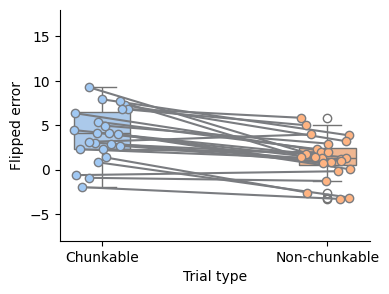

In [6]:
copyGoodData = copyData.copy()
copyGoodData = copyGoodData[numpy.abs(copyGoodData['Response error'])<=40]

meanGoodData = copyGoodData.groupby(['Subject','Trial type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()

fig,ax = pyplot.subplots(figsize=(4,3))
jlib.display.pairedObs.boxPlotPaired(ax=ax,
                                     data=meanGoodData,
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteBase)
ax.set_ylim(minBiasValue,maxBiasValue)
seaborn.despine()

In [7]:
biasGoodNCTrialData = meanGoodData[meanGoodData['Trial type']=='Non-chunkable']['Flipped error'].to_numpy()
biasGoodCTrialData = meanGoodData[meanGoodData['Trial type']=='Chunkable']['Flipped error'].to_numpy()

goodBiasTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       column1=biasGoodCTrialData,
                                                       column2=biasGoodNCTrialData,
                                                       isStudent=True,isWilcoxon=False,hypothesis='different',
                                                       effectSize=True,descriptives=True)

goodBiasTtestPS['ttest'].columns = goodBiasTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasGoodTrialsChunkingEffect",
                            jlib.data.constants.extractTtestResults(goodBiasTtestPS['ttest'],0))

goodBiasTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  6.206566  23.0  0.000002   
 
                               esType        e  
 {"i1":"set1","i2":"set2"}  Cohen's d  1.26691  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.960873  0.456212,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  3.923977  4.076951  2.950864  0.602343
 "set21"  set2   24  1.319747  1.364423  2.316241  0.472801}

In [8]:
goodBiasTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[biasGoodCTrialData,biasGoodNCTrialData],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                       effectSize=True,descriptives=True)

goodBiasTtestOS['ttest'].columns = goodBiasTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSBiasGoodTrialsChunkable",
                            jlib.data.constants.extractTtestResults(goodBiasTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSBiasGoodTrialsNonchunkable",
                            jlib.data.constants.extractTtestResults(goodBiasTtestOS['ttest'],1,2))

goodBiasTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t  6.514527  23.0  5.999555e-07  Cohen's d  1.329772
 "set1"  set1  Student's t  2.791340  23.0  5.187161e-03  Cohen's d  0.569780,
 'normality':         name         w         p
 "set0"  set0  0.978824  0.873244
 "set1"  set1  0.959483  0.428126,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  3.923977  4.076951  2.950864  0.602343
 "set1"  set1   24  1.319747  1.364423  2.316241  0.472801}

## <span style='color:Red'>Bias (chunking x cue type)</span>

In [9]:
meanCueData = copyData.groupby(['Subject','Trial type','Cue type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
meanCueData

,Subject,Trial type,Cue type,Response error,Flipped error
0,400,Chunkable,Informative,1.394056,7.459068
1,400,Chunkable,Uninformative,-1.583573,11.921356
2,400,Non-chunkable,Informative,0.675079,8.562963
3,400,Non-chunkable,Uninformative,-5.760495,5.110303
4,401,Chunkable,Informative,-1.557436,2.498161
...,...,...,...,...,...
91,431,Non-chunkable,Uninformative,-4.335192,2.139602
92,433,Chunkable,Informative,-0.953262,-1.502042
93,433,Chunkable,Uninformative,-5.514325,11.732015
94,433,Non-chunkable,Informative,6.562129,-0.377866


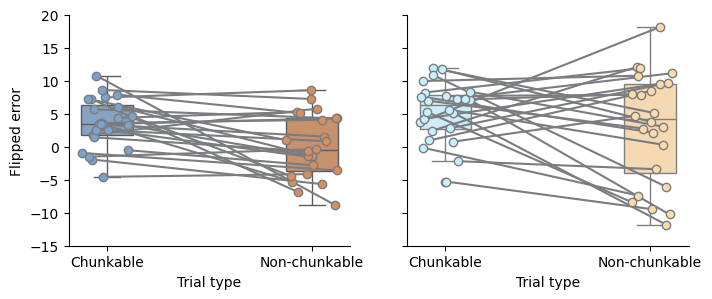

In [10]:
fig,ax = pyplot.subplots(1,2,figsize=(8,3),sharey=True)

jlib.display.pairedObs.boxPlotPaired(ax=ax[0],
                                     data=meanCueData[meanCueData['Cue type']=='Informative'],
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteInformative)
ax[0].set_ylim(-15,20)

jlib.display.pairedObs.boxPlotPaired(ax=ax[1],
                                     data=meanCueData[meanCueData['Cue type']=='Uninformative'],
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteUninformative)

seaborn.despine()

In [11]:
biasICueData = meanCueData[meanCueData['Cue type']=='Informative']['Flipped error'].to_numpy()
biasUCueData = meanCueData[meanCueData['Cue type']=='Uninformative']['Flipped error'].to_numpy()

biasCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                      column1=biasUCueData,
                                                      column2=biasICueData,
                                                      isStudent=True,isWilcoxon=False,hypothesis='different',
                                                      effectSize=True,descriptives=True)

biasCueTtestPS['ttest'].columns = biasCueTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSBiasAllTrialsCueEffect",
#                             jlib.data.constants.extractTtestResults(biasCueTtestPS['ttest'],0))

biasCueTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  2.320599  47.0  0.024698   
 
                               esType        e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.33495  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.966815  0.189778,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   48  4.178868  5.197951  6.697758  0.966738
 "set21"  set2   48  1.802461  2.535866  4.589204  0.662394}

### <span style='color:Red'>Informative cue stats</span>

In [12]:
biasNCTrialICueData = meanCueData[(meanCueData['Cue type']=='Informative') &
                                  (meanCueData['Trial type']=='Non-chunkable')]['Flipped error'].to_numpy()
biasCTrialICueData = meanCueData[(meanCueData['Cue type']=='Informative') &
                                 (meanCueData['Trial type']=='Chunkable')]['Flipped error'].to_numpy()

biasICueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       column1=biasCTrialICueData,
                                                       column2=biasNCTrialICueData,
                                                       isStudent=True,isWilcoxon=False,hypothesis='different',
                                                       effectSize=True,descriptives=True)

biasICueTtestPS['ttest'].columns = biasICueTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSBiasAllInformativeTrialsChunkingEffect",
#                             jlib.data.constants.extractTtestResults(biasICueTtestPS['ttest'],0,2))

biasICueTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  3.281994  23.0  0.003269   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.669934  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.870078  0.005279,
 'descriptives':          name  num         m       med       sd        se
 "set11"  set1   24  3.570341  3.401407  3.72683  0.760736
 "set21"  set2   24  0.034582 -0.529192  4.75662  0.970941}

In [13]:
biasICueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[biasCTrialICueData,biasNCTrialICueData],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                       effectSize=True,descriptives=True)

biasICueTtestOS['ttest'].columns = biasICueTtestOS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestOSBiasAllInformativeTrialsChunkable",
#                             jlib.data.constants.extractTtestResults(biasICueTtestOS['ttest'],0,2))

# mapValueHandler.setKeyValue("ttestOSBiasAllInformativeTrialsNonchunkable",
#                             jlib.data.constants.extractTtestResults(biasICueTtestOS['ttest'],1,2))

biasICueTtestOS

{'ttest':          var         name       sta    df         p     esType        e
 "set0"  set0  Student's t  4.693271  23.0  0.000050  Cohen's d  0.95801
 "set1"  set1  Student's t  0.035617  23.0  0.485948  Cohen's d  0.00727,
 'normality':         name         w         p
 "set0"  set0  0.981005  0.913623
 "set1"  set1  0.972098  0.718853,
 'descriptives':         name  num      mean    median       sd        se
 "set0"  set0   24  3.570341  3.401407  3.72683  0.760736
 "set1"  set1   24  0.034582 -0.529192  4.75662  0.970941}

### <span style='color:Red'>Uninformative cue stats</span>

In [14]:
biasNCTrialUCueData = meanCueData[(meanCueData['Cue type']=='Uninformative') &
                                  (meanCueData['Trial type']=='Non-chunkable')]['Flipped error'].to_numpy()
biasCTrialUCueData = meanCueData[(meanCueData['Cue type']=='Uninformative') &
                                 (meanCueData['Trial type']=='Chunkable')]['Flipped error'].to_numpy()

biasUCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       column1=biasCTrialUCueData,
                                                       column2=biasNCTrialUCueData,
                                                       isStudent=True,isWilcoxon=False,hypothesis='different',
                                                       effectSize=True,descriptives=True)

biasUCueTtestPS['ttest'].columns = biasUCueTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSBiasAllUninformativeTrialsChunkingEffect",
#                             jlib.data.constants.extractTtestResults(biasUCueTtestPS['ttest'],0,2))

biasUCueTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  1.321712  23.0  0.199261   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.269793  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.965794  0.565168,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  5.336278  6.293047  4.349737  0.887886
 "set21"  set2   24  3.021458  4.225623  8.363878  1.707269}

In [15]:
biasUCueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                       variables=[biasCTrialUCueData,biasNCTrialUCueData],
                                                       testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                       effectSize=True,descriptives=True)

biasUCueTtestOS['ttest'].columns = biasUCueTtestOS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestOSBiasAllUninformativeTrialsChunkable",
#                             jlib.data.constants.extractTtestResults(biasUCueTtestOS['ttest'],0,2))

# mapValueHandler.setKeyValue("ttestOSBiasAllUninformativeTrialsNonchunkable",
#                             jlib.data.constants.extractTtestResults(biasUCueTtestOS['ttest'],1,2))

biasUCueTtestOS

{'ttest':          var         name       sta    df         p     esType         e
 "set0"  set0  Student's t  6.010092  23.0  0.000002  Cohen's d  1.226805
 "set1"  set1  Student's t  1.769760  23.0  0.045013  Cohen's d  0.361251,
 'normality':         name         w         p
 "set0"  set0  0.960902  0.456805
 "set1"  set1  0.939972  0.162894,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  5.336278  6.293047  4.349737  0.887886
 "set1"  set1   24  3.021458  4.225623  8.363878  1.707269}

### <span style='color:Red'>Quick ANOVA</span>

In [16]:
biasDF = pandas.DataFrame({'Subject':numpy.unique(meanCueData['Subject']),
                           'ChunkableCue1Bias':biasCTrialICueData,
                           'ChunkableCue2Bias':biasCTrialUCueData,
                           'NonChunkableCue1Bias':biasNCTrialICueData,
                           'NonChunkableCue2Bias':biasNCTrialUCueData})

biasChunkingCueAnovaRM = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
                                                     data=biasDF,
                                                     rmLabels=['Trial','Cue'],
                                                     rmLists=[['Chunkable','NonChunkable'],[1,2]],
                                                     rmMeasureName='Bias',
                                                     rmTerms='~Cue+Trial+Cue:Trial',
                                                     effectSize=[desiredEffectSize])

biasChunkingCueAnovaRM['within'].columns = biasChunkingCueAnovaRM['within'].columns.str.rstrip('[none]')

# mapValueHandler.setKeyValue("anovaBiasAllVsCue",
#                             jlib.data.constants.extractAnovaResults(biasChunkingCueAnovaRM['within'],
#                                                                     0,1,desiredEffectSize))

# mapValueHandler.setKeyValue("anovaBiasAllVsChunking",
#                             jlib.data.constants.extractAnovaResults(biasChunkingCueAnovaRM['within'],
#                                                                     2,3,desiredEffectSize))

# mapValueHandler.setKeyValue("anovaBiasAllVsCueChunking",
#                             jlib.data.constants.extractAnovaResults(biasChunkingCueAnovaRM['within'],
#                                                                     4,5,desiredEffectSize))

biasChunkingCueAnovaRM

{'within':                               nam          ss    df          ms         F  \
 "Cue"                         Cue  135.535446   1.0  135.535446  4.571409   
 ["Cue",".RES"]           Residual  681.915647  23.0   29.648506       NaN   
 "Trial"                     Trial  205.375701   1.0  205.375701  6.999347   
 ["Trial",".RES"]         Residual  674.868792  23.0   29.342121       NaN   
 ["Cue","Trial"]         Cue:Trial    8.944148   1.0    8.944148  0.418081   
 ["Cue","Trial",".RES"]   Residual  492.046815  23.0   21.393340       NaN   
 
                                p       ges  
 "Cue"                   0.043361  0.044887  
 ["Cue",".RES"]               NaN       NaN  
 "Trial"                 0.014451  0.066479  
 ["Trial",".RES"]             NaN       NaN  
 ["Cue","Trial"]         0.524297  0.003092  
 ["Cue","Trial",".RES"]       NaN       NaN  ,
 'between':                 name           ss    df         ms           F           p  \
 "Residual"  Residual  1035.1

### <span style='color:Red'>Chunkable trials stats</span>

In [17]:
biasCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                         column1=biasCTrialUCueData,
                                                         column2=biasCTrialICueData,
                                                         isStudent=True,isWilcoxon=False,hypothesis='different',
                                                         effectSize=True,descriptives=True)

biasCTrialTtestPS['ttest'].columns = biasCTrialTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSBiasAllChunkingTrialsCueEffect",
#                             jlib.data.constants.extractTtestResults(biasCTrialTtestPS['ttest'],0,2))

biasCTrialTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  1.817401  23.0  0.082208   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.370975  ,
 'normality':                            var1 sep  var2        w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.97822  0.860935,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  5.336278  6.293047  4.349737  0.887886
 "set21"  set2   24  3.570341  3.401407  3.726830  0.760736}

### <span style='color:Red'>Non-chunkable trials stats</span>

In [18]:
biasNCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                          column1=biasNCTrialUCueData,
                                                          column2=biasNCTrialICueData,
                                                          isStudent=True,isWilcoxon=False,hypothesis='different',
                                                          effectSize=True,descriptives=True)

biasNCTrialTtestPS['ttest'].columns = biasNCTrialTtestPS['ttest'].columns.str.rstrip('[stud]')

# mapValueHandler.setKeyValue("ttestPSBiasAllNonchunkingTrialsCueEffect",
#                             jlib.data.constants.extractTtestResults(biasNCTrialTtestPS['ttest'],0,2))

biasNCTrialTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  1.641905  23.0  0.114214   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.335152  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.976419  0.821869,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  3.021458  4.225623  8.363878  1.707269
 "set21"  set2   24  0.034582 -0.529192  4.756620  0.970941}

### <span style='color:Red'>Only consider trials with abs(error) < 40</span>

In [19]:
meanGoodCueData = copyGoodData.groupby(['Subject','Trial type','Cue type'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
meanGoodCueData

,Subject,Trial type,Cue type,Response error,Flipped error
0,400,Chunkable,Informative,2.141826,7.350283
1,400,Chunkable,Uninformative,-0.258524,8.520179
2,400,Non-chunkable,Informative,-2.047143,6.059008
3,400,Non-chunkable,Uninformative,-2.125214,1.282774
4,401,Chunkable,Informative,-0.933881,5.215845
...,...,...,...,...,...
91,431,Non-chunkable,Uninformative,-1.897605,2.394770
92,433,Chunkable,Informative,-1.359066,-1.101213
93,433,Chunkable,Uninformative,-3.293084,-0.549309
94,433,Non-chunkable,Informative,1.100277,-1.304455


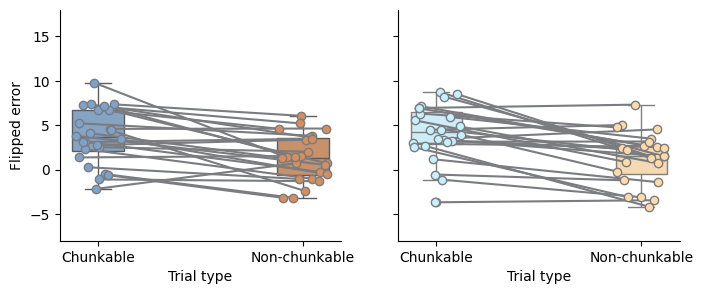

In [20]:
fig,ax = pyplot.subplots(1,2,figsize=(8,3),sharey=True)

jlib.display.pairedObs.boxPlotPaired(ax=ax[0],
                                     data=meanGoodCueData[meanGoodCueData['Cue type']=='Informative'],
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteInformative)
ax[0].set_ylim(minBiasValue,maxBiasValue)

jlib.display.pairedObs.boxPlotPaired(ax=ax[1],
                                     data=meanGoodCueData[meanGoodCueData['Cue type']=='Uninformative'],
                                     x='Trial type',y='Flipped error',
                                     width=0.25,palette=paletteUninformative)
ax[1].set_ylim(minBiasValue,maxBiasValue)

seaborn.despine()

In [21]:
biasGoodICueData = meanGoodCueData[meanGoodCueData['Cue type']=='Informative']['Flipped error'].to_numpy()
biasGoodUCueData = meanGoodCueData[meanGoodCueData['Cue type']=='Uninformative']['Flipped error'].to_numpy()

biasGoodCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                          column1=biasGoodUCueData,
                                                          column2=biasGoodICueData,
                                                          isStudent=False,isWilcoxon=True,hypothesis='different',
                                                          effectSize=True,descriptives=True)

biasGoodCueTtestPS['ttest'].columns = biasGoodCueTtestPS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestPSBiasGoodTrialsCueEffect",
                            jlib.data.constants.extractWilcoxonResults(biasGoodCueTtestPS['ttest'],0))

biasGoodCueTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  688.0  0.310468   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.170068  ,
 'normality':                            var1 sep  var2         w        p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.948345  0.03437,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   48  2.712017  2.830550  3.300083  0.476326
 "set21"  set2   48  2.513205  2.650627  3.109625  0.448836}

In [22]:
biasGoodNCTrialICueData = meanGoodCueData[(meanGoodCueData['Cue type']=='Informative') &
                                          (meanGoodCueData['Trial type']=='Non-chunkable')]['Flipped error'].to_numpy()
biasGoodCTrialICueData = meanGoodCueData[(meanGoodCueData['Cue type']=='Informative') &
                                         (meanGoodCueData['Trial type']=='Chunkable')]['Flipped error'].to_numpy()

biasGoodICueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=biasGoodCTrialICueData,
                                                           column2=biasGoodNCTrialICueData,
                                                           isStudent=True,isWilcoxon=False,hypothesis='different',
                                                           effectSize=True,descriptives=True)

biasGoodICueTtestPS['ttest'].columns = biasGoodICueTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasGoodInformativeTrialsChunkingEffect",
                            jlib.data.constants.extractTtestResults(biasGoodICueTtestPS['ttest'],0,2))

biasGoodICueTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  4.508405  23.0  0.000159   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.920274  ,
 'normality':                            var1 sep  var2         w        p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.975278  0.79565,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  3.710047  3.621384  3.136220  0.640178
 "set21"  set2   24  1.316363  1.341082  2.633374  0.537535}

In [23]:
biasGoodICueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=[biasGoodCTrialICueData,
                                                                      biasGoodNCTrialICueData],
                                                           testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                           effectSize=True,descriptives=True)

biasGoodICueTtestOS['ttest'].columns = biasGoodICueTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSBiasGoodInformativeTrialsChunkable",
                            jlib.data.constants.extractTtestResults(biasGoodICueTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSBiasGoodInformativeTrialsNonchunkable",
                            jlib.data.constants.extractTtestResults(biasGoodICueTtestOS['ttest'],1,2))

biasGoodICueTtestOS

{'ttest':          var         name       sta    df         p     esType         e
 "set0"  set0  Student's t  5.795334  23.0  0.000003  Cohen's d  1.182968
 "set1"  set1  Student's t  2.448887  23.0  0.011185  Cohen's d  0.499877,
 'normality':         name         w        p
 "set0"  set0  0.968504  0.63019
 "set1"  set1  0.968610  0.63279,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  3.710047  3.621384  3.136220  0.640178
 "set1"  set1   24  1.316363  1.341082  2.633374  0.537535}

In [24]:
biasGoodNCTrialUCueData = meanGoodCueData[(meanGoodCueData['Cue type']=='Uninformative') &
                                           (meanGoodCueData['Trial type']=='Non-chunkable')]['Flipped error'].to_numpy()
biasGoodCTrialUCueData = meanGoodCueData[(meanGoodCueData['Cue type']=='Uninformative') &
                                        (meanGoodCueData['Trial type']=='Chunkable')]['Flipped error'].to_numpy()

biasGoodUCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           column1=biasGoodCTrialUCueData,
                                                           column2=biasGoodNCTrialUCueData,
                                                           isStudent=True,isWilcoxon=False,hypothesis='different',
                                                           effectSize=True,descriptives=True)

biasGoodUCueTtestPS['ttest'].columns = biasGoodUCueTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasGoodUninformativeTrialsChunkingEffect",
                            jlib.data.constants.extractTtestResults(biasGoodUCueTtestPS['ttest'],0,2))

biasGoodUCueTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  5.196755  23.0  0.000029   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  1.060783  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.935789  0.131358,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  4.128922  4.211531  3.095306  0.631827
 "set21"  set2   24  1.295113  1.501299  2.912708  0.594554}

In [25]:
biasGoodUCueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                           variables=[biasGoodCTrialUCueData,
                                                                      biasGoodNCTrialUCueData],
                                                           testValue=0,isStudent=True,isWilcoxon=False,hypothesis='gt',
                                                           effectSize=True,descriptives=True)

biasGoodUCueTtestOS['ttest'].columns = biasGoodUCueTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSBiasGoodUninformativeTrialsChunkable",
                            jlib.data.constants.extractTtestResults(biasGoodUCueTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSBiasGoodUninformativeTrialsNonchunkable",
                            jlib.data.constants.extractTtestResults(biasGoodUCueTtestOS['ttest'],1,2))

biasGoodUCueTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t  6.534896  23.0  5.720739e-07  Cohen's d  1.333930
 "set1"  set1  Student's t  2.178294  23.0  1.994442e-02  Cohen's d  0.444642,
 'normality':         name         w         p
 "set0"  set0  0.954138  0.332216
 "set1"  set1  0.965842  0.566299,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24  4.128922  4.211531  3.095306  0.631827
 "set1"  set1   24  1.295113  1.501299  2.912708  0.594554}

In [26]:
biasGoodDF = pandas.DataFrame({'Subject':numpy.unique(meanGoodCueData['Subject']),
                               'ChunkableCue1Bias':biasGoodCTrialICueData,
                               'ChunkableCue2Bias':biasGoodCTrialUCueData,
                               'NonChunkableCue1Bias':biasGoodNCTrialICueData,
                               'NonChunkableCue2Bias':biasGoodNCTrialUCueData})

biasGoodChunkingCueAnovaRM = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
                                                         data=biasGoodDF,
                                                         rmLabels=['Trial','Cue'],
                                                         rmLists=[['Chunkable','NonChunkable'],[1,2]],
                                                         rmMeasureName='Bias',
                                                         rmTerms='~Cue+Trial+Cue:Trial',
                                                         effectSize=[desiredEffectSize])

biasGoodChunkingCueAnovaRM['within'].columns = biasGoodChunkingCueAnovaRM['within'].columns.str.rstrip('[none]')

mapValueHandler.setKeyValue("anovaBiasGoodVsCue",
                            jlib.data.constants.extractAnovaResults(biasGoodChunkingCueAnovaRM['within'],
                                                                    0,1,desiredEffectSize))

mapValueHandler.setKeyValue("anovaBiasGoodVsChunking",
                            jlib.data.constants.extractAnovaResults(biasGoodChunkingCueAnovaRM['within'],
                                                                    2,3,desiredEffectSize))

mapValueHandler.setKeyValue("anovaBiasGoodVsCueChunking",
                            jlib.data.constants.extractAnovaResults(biasGoodChunkingCueAnovaRM['within'],
                                                                    4,5,desiredEffectSize))

biasGoodChunkingCueAnovaRM

{'within':                               nam          ss    df          ms          F  \
 "Cue"                         Cue    0.948634   1.0    0.948634   0.241309   
 ["Cue",".RES"]           Residual   90.417614  23.0    3.931201        NaN   
 "Trial"                     Trial  163.960059   1.0  163.960059  38.666904   
 ["Trial",".RES"]         Residual   97.527368  23.0    4.240320        NaN   
 ["Cue","Trial"]         Cue:Trial    1.162254   1.0    1.162254   0.428767   
 ["Cue","Trial",".RES"]   Residual   62.345940  23.0    2.710693        NaN   
 
                                p       ges  
 "Cue"                   0.627917  0.001183  
 ["Cue",".RES"]               NaN       NaN  
 "Trial"                 0.000002  0.169876  
 ["Trial",".RES"]             NaN       NaN  
 ["Cue","Trial"]         0.519090  0.001449  
 ["Cue","Trial",".RES"]       NaN       NaN  ,
 'between':                 name          ss    df         ms           F           p  \
 "Residual"  Residual  

In [27]:
biasGoodCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                             column1=biasGoodCTrialUCueData,
                                                             column2=biasGoodCTrialICueData,
                                                             isStudent=False,isWilcoxon=True,hypothesis='different',
                                                             effectSize=True,descriptives=True)

biasGoodCTrialTtestPS['ttest'].columns = biasGoodCTrialTtestPS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestPSBiasGoodChunkingTrialsCueEffect",
                            jlib.data.constants.extractWilcoxonResults(biasGoodCTrialTtestPS['ttest'],0,2))

biasGoodCTrialTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  207.0  0.107383   
 
                                               esType    es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation  0.38  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.910292  0.035787,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  4.128922  4.211531  3.095306  0.631827
 "set21"  set2   24  3.710047  3.621384  3.136220  0.640178}

In [28]:
biasGoodNCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                              column1=biasGoodNCTrialUCueData,
                                                              column2=biasGoodNCTrialICueData,
                                                              isStudent=False,isWilcoxon=True,hypothesis='different',
                                                              effectSize=True,descriptives=True)

biasGoodNCTrialTtestPS['ttest'].columns = biasGoodNCTrialTtestPS['ttest'].columns.str.rstrip('[wilc]')

mapValueHandler.setKeyValue("ttestPSBiasGoodNonchunkingTrialsCueEffect",
                            jlib.data.constants.extractWilcoxonResults(biasGoodNCTrialTtestPS['ttest'],0,2))

biasGoodNCTrialTtestPS

{'ttest':                            var1  var2        test   stat         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Wilcoxon W  148.0  0.966447   
 
                                               esType        es  
 {"i1":"set1","i2":"set2"}  Rank biserial correlation -0.013333  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.966295  0.576981,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24  1.295113  1.501299  2.912708  0.594554
 "set21"  set2   24  1.316363  1.341082  2.633374  0.537535}

## <span style='color:Red'>Bias = f(distance to mean)</span>

In [29]:
distCopyData = allParticipantData.copy()
nTargets = numpy.unique(distCopyData['Target']).shape[0]

distCopyData['Distance to mean'] = distCopyData.apply(
    lambda x: jlib.compression.experimentValues.splitByDistanceToMean(x,5,
                                                                      jlib.compression.constants.EXP4_OFFSET_ANGLE,
                                                                      nTargets,
                                                                      jlib.compression.constants.EXP4_RESPONSE_SECTIONS,
                                                                      expType='Exp4'),axis=1)

columnsToKeep = ['Subject','Trial type','Response error','Flipped error','Cue type','Distance to mean']
distCopyData.drop([column for column in distCopyData.columns if column not in columnsToKeep],axis=1,inplace=True)

angleColumns = [column for column in distCopyData.columns if column not in ['Subject','Trial type','Cue type','Distance to mean']]
distMeanData = distCopyData.groupby(['Subject','Trial type','Distance to mean'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
distMeanData

,Subject,Trial type,Distance to mean,Response error,Flipped error
0,400,Chunkable,-16.0,12.839314,12.839314
1,400,Chunkable,-8.0,11.046546,11.046546
2,400,Chunkable,0.0,-0.401944,-0.138430
3,400,Chunkable,8.0,-11.254927,11.254927
4,400,Chunkable,16.0,-13.153147,13.153147
...,...,...,...,...,...
235,433,Non-chunkable,-16.0,9.751314,9.751314
236,433,Non-chunkable,-8.0,-1.102196,-1.102196
237,433,Non-chunkable,0.0,21.595096,9.993380
238,433,Non-chunkable,8.0,-0.983462,0.983462


C:\Users\juanm\AppData\Local\Temp\ipykernel_68244\563686418.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])


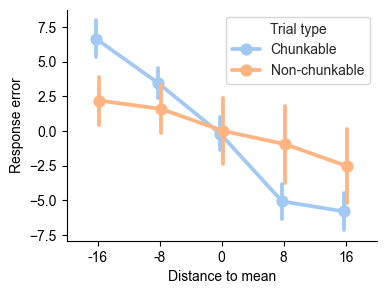

In [30]:
fig,ax = pyplot.subplots(figsize=(4,3))
seaborn.set_style('ticks')

seaborn.pointplot(ax=ax,
                  data=distMeanData,
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
ax.set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])
# ax.set_ylim(minBiasValue,maxBiasValue)

seaborn.despine()

### <span style='color:Red'>Only consider trials with abs(error) < 40</span>

In [31]:
distGoodCopyData = distCopyData.copy()
distGoodCopyData = distGoodCopyData[numpy.abs(distGoodCopyData['Response error'])<=40]

angleColumns = [column for column in distGoodCopyData.columns if column not in ['Subject','Trial type','Cue type','Distance to mean']]
distGoodMeanData = distGoodCopyData.groupby(['Subject','Trial type','Distance to mean'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
distGoodMeanData

,Subject,Trial type,Distance to mean,Response error,Flipped error
0,400,Chunkable,-16.0,11.596168,11.596168
1,400,Chunkable,-8.0,9.651428,9.651428
2,400,Chunkable,0.0,0.860381,0.870285
3,400,Chunkable,8.0,-7.092709,7.092709
4,400,Chunkable,16.0,-11.238571,11.238571
...,...,...,...,...,...
235,433,Non-chunkable,-16.0,-2.289527,-2.289527
236,433,Non-chunkable,-8.0,-1.458349,-1.458349
237,433,Non-chunkable,0.0,4.181998,7.018947
238,433,Non-chunkable,8.0,0.417557,-0.417557


C:\Users\juanm\AppData\Local\Temp\ipykernel_68244\3760848650.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])


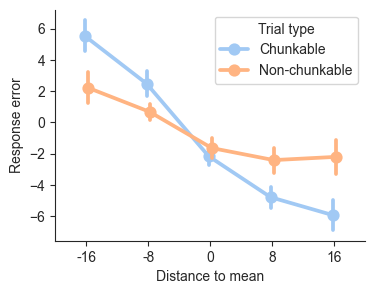

In [32]:
fig,ax = pyplot.subplots(figsize=(4,3))
seaborn.set_style('ticks')

seaborn.pointplot(ax=ax,
                  data=distGoodMeanData,
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteBase)
ax.set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax.get_xticklabels()])
# ax.set_ylim(minAccuracyValue,maxAccuracyValue)

seaborn.despine()

## <span style='color:Red'>Bias = f(chunking,cue type,distance to mean)</span>

In [33]:
distMeanCueData = distCopyData.groupby(['Subject','Trial type','Cue type','Distance to mean'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
distMeanCueData

,Subject,Trial type,Cue type,Distance to mean,Response error,Flipped error
0,400,Chunkable,Informative,-16.0,12.558847,12.558847
1,400,Chunkable,Informative,-8.0,6.703049,6.703049
2,400,Chunkable,Informative,0.0,4.007461,2.429319
3,400,Chunkable,Informative,8.0,-6.113817,6.113817
4,400,Chunkable,Informative,16.0,-12.205600,12.205600
...,...,...,...,...,...,...
475,433,Non-chunkable,Uninformative,-16.0,-16.227793,-16.227793
476,433,Non-chunkable,Uninformative,-8.0,16.218639,16.218639
477,433,Non-chunkable,Uninformative,0.0,51.981554,25.872980
478,433,Non-chunkable,Uninformative,8.0,46.674307,-46.674307


C:\Users\juanm\AppData\Local\Temp\ipykernel_68244\1569478961.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[0].get_xticklabels()])
C:\Users\juanm\AppData\Local\Temp\ipykernel_68244\1569478961.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[1].get_xticklabels()])


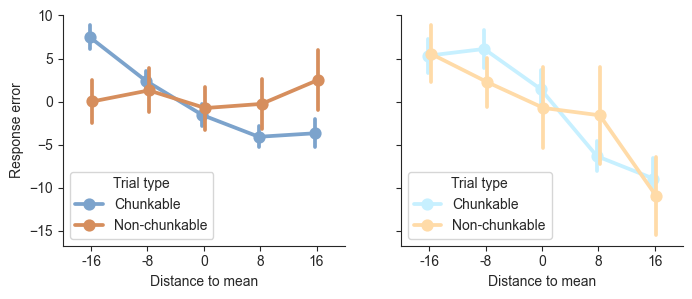

In [34]:
fig,ax = pyplot.subplots(1,2,figsize=(8,3),sharey=True)
seaborn.pointplot(ax=ax[0],
                  data=distMeanCueData[distMeanCueData['Cue type']=='Informative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteInformative)
ax[0].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[0].get_xticklabels()])

seaborn.pointplot(ax=ax[1],
                  data=distMeanCueData[distMeanCueData['Cue type']=='Uninformative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteUninformative)
ax[1].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[1].get_xticklabels()])

seaborn.despine()

### <span style='color:Red'>Only consider trials with abs(error) < 40</span>

In [35]:
distGoodCueMeanData = distGoodCopyData.groupby(['Subject','Trial type','Cue type','Distance to mean'])[angleColumns].apply(
    lambda x: pandas.Series({col: jlib.analysis.circularStats.circularMean(x[col].to_numpy()) for col in angleColumns})).reset_index()
distGoodCueMeanData

,Subject,Trial type,Cue type,Distance to mean,Response error,Flipped error
0,400,Chunkable,Informative,-16.0,13.649105,13.649105
1,400,Chunkable,Informative,-8.0,8.215063,8.215063
2,400,Chunkable,Informative,0.0,2.970905,1.561397
3,400,Chunkable,Informative,8.0,-4.950060,4.950060
4,400,Chunkable,Informative,16.0,-11.418658,11.418658
...,...,...,...,...,...,...
475,433,Non-chunkable,Uninformative,-16.0,-3.143056,-3.143056
476,433,Non-chunkable,Uninformative,-8.0,1.400793,1.400793
477,433,Non-chunkable,Uninformative,0.0,25.584031,25.584031
478,433,Non-chunkable,Uninformative,8.0,6.663559,-6.663559


C:\Users\juanm\AppData\Local\Temp\ipykernel_68244\49802854.py:6: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[0].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[0].get_xticklabels()])
C:\Users\juanm\AppData\Local\Temp\ipykernel_68244\49802854.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[1].get_xticklabels()])


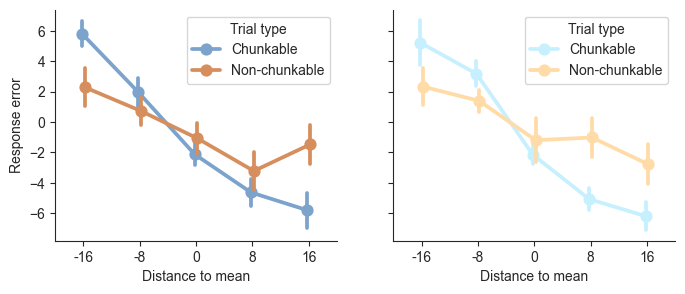

In [36]:
fig,ax = pyplot.subplots(1,2,figsize=(8,3),sharey=True)
seaborn.pointplot(ax=ax[0],
                  data=distGoodCueMeanData[distGoodCueMeanData['Cue type']=='Informative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteInformative)
ax[0].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[0].get_xticklabels()])

seaborn.pointplot(ax=ax[1],
                  data=distGoodCueMeanData[distGoodCueMeanData['Cue type']=='Uninformative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,estimator=numpy.nanmean,palette=paletteUninformative)
ax[1].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[1].get_xticklabels()])

seaborn.despine()

### <span style='color:Red'>Fit slopes and compare them</span>

In [37]:
columnsToKeep = ['Subject','Trial type','Response error','True target','Cue type']

distGoodModelData = allParticipantData.copy()
distGoodModelData = distGoodModelData[numpy.abs(distGoodModelData['Response error'])<=40]
distGoodModelData['True target'] = (distGoodModelData['Continuous target']-distGoodModelData['Mean target'])/3
distGoodModelData.drop([column for column in distGoodModelData.columns if column not in columnsToKeep],axis=1,inplace=True)

allFitsC_I = []
allFitsC_U = []
allFitsNC_I = []
allFitsNC_U = []

optimizationBounds = (numpy.array([-numpy.inf,-numpy.inf]),numpy.array([numpy.inf,numpy.inf]))

for participant in numpy.unique(distGoodModelData['Subject']):
    participantModelData = distGoodModelData[distGoodModelData['Subject']==participant]
    # print('Fitting data for participant',participant)
    # Fit chunkable trials / informative cue
    xC_I = participantModelData[(participantModelData['Trial type']=='Chunkable') &
                                (participantModelData['Cue type']=='Informative')]['True target'].to_numpy()
    yC_I = participantModelData[(participantModelData['Trial type']=='Chunkable') &
                                (participantModelData['Cue type']=='Informative')]['Response error'].to_numpy()
    fitStartingPointC_I = [0,numpy.mean(yC_I)]
    fitC_I = jlib.analysis.models.fitLine(xC_I,yC_I,fitStartingPointC_I,optimizationBounds)
    allFitsC_I.append(fitC_I.x)
    # Fit chunkable trials / uninformative cue
    xC_U = participantModelData[(participantModelData['Trial type']=='Chunkable') &
                                (participantModelData['Cue type']=='Uninformative')]['True target'].to_numpy()
    yC_U = participantModelData[(participantModelData['Trial type']=='Chunkable') &
                                (participantModelData['Cue type']=='Uninformative')]['Response error'].to_numpy()
    fitStartingPointC_U = [0,numpy.mean(yC_U)]
    fitC_U = jlib.analysis.models.fitLine(xC_U,yC_U,fitStartingPointC_U,optimizationBounds)
    allFitsC_U.append(fitC_U.x)
    # Fit non-chunkable trials / informative cue
    xNC_I = participantModelData[(participantModelData['Trial type']=='Non-chunkable') &
                                 (participantModelData['Cue type']=='Informative')]['True target'].to_numpy()
    yNC_I = participantModelData[(participantModelData['Trial type']=='Non-chunkable') &
                                 (participantModelData['Cue type']=='Informative')]['Response error'].to_numpy()
    fitStartingPointNC_I = [0,numpy.mean(yNC_I)]
    fitNC_I = jlib.analysis.models.fitLine(xNC_I,yNC_I,fitStartingPointNC_I,optimizationBounds)
    allFitsNC_I.append(fitNC_I.x)
    # Fit non-chunkable trials / informative cue
    xNC_U = participantModelData[(participantModelData['Trial type']=='Non-chunkable') &
                                 (participantModelData['Cue type']=='Uninformative')]['True target'].to_numpy()
    yNC_U = participantModelData[(participantModelData['Trial type']=='Non-chunkable') &
                                 (participantModelData['Cue type']=='Uninformative')]['Response error'].to_numpy()
    fitStartingPointNC_U = [0,numpy.mean(yNC_U)]
    fitNC_U = jlib.analysis.models.fitLine(xNC_U,yNC_U,fitStartingPointNC_U,optimizationBounds)
    allFitsNC_U.append(fitNC_U.x)

allFitsC_I = numpy.array(allFitsC_I)
allFitsC_U = numpy.array(allFitsC_U)
allFitsNC_I = numpy.array(allFitsNC_I)
allFitsNC_U = numpy.array(allFitsNC_U)

In [38]:
biasSlopesNCTrialICue = allFitsNC_I[:,0]
biasSlopesCTrialICue = allFitsC_I[:,0]

biasSlopeICueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            column1=biasSlopesNCTrialICue,column2=biasSlopesCTrialICue,
                                                            isStudent=True,isWilcoxon=False,hypothesis='different',
                                                            effectSize=True,descriptives=True)

biasSlopeICueTtestPS['ttest'].columns = biasSlopeICueTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasSlopeGoodICueTrialsChunkingEffect",
                            jlib.data.constants.extractTtestResults(biasSlopeICueTtestPS['ttest'],0,2))

biasSlopeICueTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  3.677735  23.0  0.001248   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.750715  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.953933  0.328918,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24 -0.152402 -0.157528  0.286277  0.058436
 "set21"  set2   24 -0.373358 -0.412931  0.289442  0.059082}

In [39]:
biasSlopeICueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            variables=[biasSlopesCTrialICue,biasSlopesNCTrialICue],
                                                            testValue=0,isStudent=True,isWilcoxon=False,hypothesis='lt',
                                                            effectSize=True,descriptives=True)

biasSlopeICueTtestOS['ttest'].columns = biasSlopeICueTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSBiasSlopeGoodICueTrialsChunkable",
                            jlib.data.constants.extractTtestResults(biasSlopeICueTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSBiasSlopeGoodICueTrialsNonchunkable",
                            jlib.data.constants.extractTtestResults(biasSlopeICueTtestOS['ttest'],1,2))

biasSlopeICueTtestOS

{'ttest':          var         name       sta    df             p     esType         e
 "set0"  set0  Student's t -6.319303  23.0  9.490642e-07  Cohen's d -1.289922
 "set1"  set1  Student's t -2.608008  23.0  7.862646e-03  Cohen's d -0.532357,
 'normality':         name         w         p
 "set0"  set0  0.963491  0.512465
 "set1"  set1  0.963592  0.514700,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24 -0.373358 -0.412931  0.289442  0.059082
 "set1"  set1   24 -0.152402 -0.157528  0.286277  0.058436}

In [40]:
biasSlopesNCTrialUCue = allFitsNC_U[:,0]
biasSlopesCTrialUCue = allFitsC_U[:,0]

biasSlopeUCueTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            column1=biasSlopesNCTrialUCue,column2=biasSlopesCTrialUCue,
                                                            isStudent=True,isWilcoxon=False,hypothesis='different',
                                                            effectSize=True,descriptives=True)

biasSlopeUCueTtestPS['ttest'].columns = biasSlopeUCueTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasSlopeGoodUCueTrialsChunkingEffect",
                            jlib.data.constants.extractTtestResults(biasSlopeUCueTtestPS['ttest'],0,2))

biasSlopeUCueTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t  4.079048  23.0  0.000462   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d  0.832632  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.976096  0.814552,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24 -0.156702 -0.177295  0.276036  0.056346
 "set21"  set2   24 -0.375848 -0.373036  0.311799  0.063646}

In [41]:
biasSlopeUCueTtestOS = jlib.analysis.ttest.ttestOSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                            variables=[biasSlopesCTrialUCue,biasSlopesNCTrialUCue],
                                                            testValue=0,isStudent=True,isWilcoxon=False,hypothesis='lt',
                                                            effectSize=True,descriptives=True)

biasSlopeUCueTtestOS['ttest'].columns = biasSlopeUCueTtestOS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestOSBiasSlopeGoodUCueTrialsChunkable",
                            jlib.data.constants.extractTtestResults(biasSlopeUCueTtestOS['ttest'],0,2))

mapValueHandler.setKeyValue("ttestOSBiasSlopeGoodUCueTrialsNonchunkable",
                            jlib.data.constants.extractTtestResults(biasSlopeUCueTtestOS['ttest'],1,2))

biasSlopeUCueTtestOS

{'ttest':          var         name       sta    df         p     esType         e
 "set0"  set0  Student's t -5.905328  23.0  0.000003  Cohen's d -1.205420
 "set1"  set1  Student's t -2.781095  23.0  0.005310  Cohen's d -0.567689,
 'normality':         name         w         p
 "set0"  set0  0.971063  0.693279
 "set1"  set1  0.951003  0.284800,
 'descriptives':         name  num      mean    median        sd        se
 "set0"  set0   24 -0.375848 -0.373036  0.311799  0.063646
 "set1"  set1   24 -0.156702 -0.177295  0.276036  0.056346}

In [42]:
biasSlopeCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                              column1=biasSlopesCTrialUCue,column2=biasSlopesCTrialICue,
                                                              isStudent=True,isWilcoxon=False,hypothesis='different',
                                                              effectSize=True,descriptives=True)

biasSlopeCTrialTtestPS['ttest'].columns = biasSlopeCTrialTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasSlopeGoodCTrialsCueEffect",
                            jlib.data.constants.extractTtestResults(biasSlopeCTrialTtestPS['ttest'],0,2))

biasSlopeCTrialTtestPS

{'ttest':                            var1  var2           te     sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t -0.0678  23.0  0.946531   
 
                               esType        e  
 {"i1":"set1","i2":"set2"}  Cohen's d -0.01384  ,
 'normality':                            var1 sep  var2         w        p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.929705  0.09602,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24 -0.375848 -0.373036  0.311799  0.063646
 "set21"  set2   24 -0.373358 -0.412931  0.289442  0.059082}

In [43]:
biasSlopeNCTrialTtestPS = jlib.analysis.ttest.ttestPSFromArray(rPath='C:/Program Files/R/R-4.4.1/',
                                                               column1=biasSlopesNCTrialUCue,column2=biasSlopesNCTrialICue,
                                                               isStudent=True,isWilcoxon=False,hypothesis='different',
                                                               effectSize=True,descriptives=True)

biasSlopeNCTrialTtestPS['ttest'].columns = biasSlopeNCTrialTtestPS['ttest'].columns.str.rstrip('[stud]')

mapValueHandler.setKeyValue("ttestPSBiasSlopeGoodNCTrialsCueEffect",
                            jlib.data.constants.extractTtestResults(biasSlopeNCTrialTtestPS['ttest'],0,2))

biasSlopeNCTrialTtestPS

{'ttest':                            var1  var2           te       sta    df         p  \
 {"i1":"set1","i2":"set2"}  set1  set2  Student's t -0.076349  23.0  0.939801   
 
                               esType         e  
 {"i1":"set1","i2":"set2"}  Cohen's d -0.015585  ,
 'normality':                            var1 sep  var2         w         p
 {"i1":"set1","i2":"set2"}  set1   -  set2  0.923928  0.071378,
 'descriptives':          name  num         m       med        sd        se
 "set11"  set1   24 -0.156702 -0.177295  0.276036  0.056346
 "set21"  set2   24 -0.152402 -0.157528  0.286277  0.058436}

In [44]:
biasSlopeDF = pandas.DataFrame({'Subject':numpy.unique(distGoodModelData['Subject']),
                                'ChunkableCue1Slope':biasSlopesCTrialICue,
                                'ChunkableCue2Slope':biasSlopesCTrialUCue,
                                'NonChunkableCue1Slope':biasSlopesNCTrialICue,
                                'NonChunkableCue2Slope':biasSlopesNCTrialUCue})

biasSlopeAnovaRM = jlib.analysis.anova.anovaRM(rPath='C:/Program Files/R/R-4.4.1/',
                                               data=biasSlopeDF,
                                               rmLabels=['Trial','Cue'],
                                               rmLists=[['Chunkable','NonChunkable'],[1,2]],
                                               rmMeasureName='Slope',
                                               rmTerms='~Cue+Trial+Cue:Trial',
                                               effectSize=[desiredEffectSize])

biasSlopeAnovaRM['within'].columns = biasSlopeAnovaRM['within'].columns.str.rstrip('[none]')

mapValueHandler.setKeyValue("anovaBiasSlopeGoodVsCue",
                            jlib.data.constants.extractAnovaResults(biasSlopeAnovaRM['within'],
                                                                    0,1,desiredEffectSize))

mapValueHandler.setKeyValue("anovaBiasSlopeGoodVsChunking",
                            jlib.data.constants.extractAnovaResults(biasSlopeAnovaRM['within'],
                                                                    2,3,desiredEffectSize))

mapValueHandler.setKeyValue("anovaBiasSlopeGoodVsCueChunking",
                            jlib.data.constants.extractAnovaResults(biasSlopeAnovaRM['within'],
                                                                    4,5,desiredEffectSize))

biasSlopeAnovaRM

{'within':                               nam        ss    df        ms          F  \
 "Cue"                         Cue  0.000277   1.0  0.000277   0.007855   
 ["Cue",".RES"]           Residual  0.810352  23.0  0.035233        NaN   
 "Trial"                     Trial  1.162139   1.0  1.162139  19.726662   
 ["Trial",".RES"]         Residual  1.354978  23.0  0.058912        NaN   
 ["Cue","Trial"]         Cue:Trial  0.000020   1.0  0.000020   0.001033   
 ["Cue","Trial",".RES"]   Residual  0.437886  23.0  0.019039        NaN   
 
                                p       ges  
 "Cue"                   0.930146  0.000035  
 ["Cue",".RES"]               NaN       NaN  
 "Trial"                 0.000187  0.129667  
 ["Trial",".RES"]             NaN       NaN  
 ["Cue","Trial"]         0.974643  0.000003  
 ["Cue","Trial",".RES"]       NaN       NaN  ,
 'between':                 name       ss    df        ms           F           p  \
 "Residual"  Residual  5.19712  23.0  0.225962 -2147483

In [45]:
mapValueHandler.saveData()

All data saved correctly to exports/exp4Values.csv


## <span style='color:Red'>Figures for publication</span>

### <span style='color:Red'>Bias</span>

C:\Users\juanm\AppData\Local\Temp\ipykernel_68244\1440251839.py:47: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax[1].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[1].get_xticklabels()])


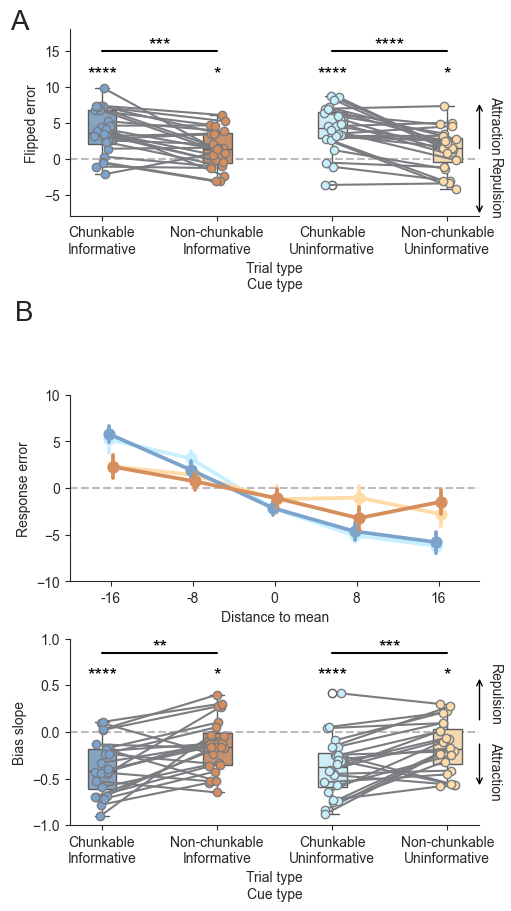

In [46]:
# Create the figure
fig,ax = pyplot.subplots(3,1,figsize=(5,9),constrained_layout=True)
seaborn.set_style('ticks')

# Ax[0]: bias as function of chunking/cue
ax[0].plot([-0.28,3.28],[0,0],'--',color='#bbbbbb')
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax[0],
                                            data=meanGoodCueData,
                                            y='Flipped error',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
# ax[0].set_ylabel("")
ax[0].set_ylim(minBiasValue,maxBiasValue)
ax[0].set_xlim(-0.28,3.28)
jlib.display.utils.displayPairwiseSignificance(ax[0],[0,1],15*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasGoodICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[0],[2,3],15*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasGoodUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[0],0,11,size=significanceSize,
                                                p=2*biasGoodICueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[0],1,11,size=significanceSize,
                                                p=2*biasGoodICueTtestOS['ttest']['p'].to_numpy()[1])
jlib.display.utils.displayOneSampleSignificance(ax[0],2,11,size=significanceSize,
                                                p=2*biasGoodUCueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[0],3,11,size=significanceSize,
                                                p=2*biasGoodUCueTtestOS['ttest']['p'].to_numpy()[1])
ax[0].annotate('',xy=(1,0),xytext=(1,7/26),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax[0].annotate('Attraction',xy=(0,0),xytext=(1.02,9/26),textcoords='axes fraction',rotation=-90)
ax[0].annotate('',xy=(1,16/26),xytext=(1,9/26),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax[0].annotate('Repulsion',xy=(0,0),xytext=(1.02,0),textcoords='axes fraction',rotation=-90)
ax[0].text(-0.8,18,'A',fontsize=20)

# Ax[1]: bias as a function of distance to mean
ax[1].plot([-0.5,4.5],[0,0],'--',color='#bbbbbb')
seaborn.pointplot(ax=ax[1],
                  data=distGoodCueMeanData[distGoodCueMeanData['Cue type']=='Uninformative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,palette=paletteUninformative)
seaborn.pointplot(ax=ax[1],
                  data=distGoodCueMeanData[distGoodCueMeanData['Cue type']=='Informative'],
                  x='Distance to mean',y='Response error',hue='Trial type',
                  errorbar='se',dodge=True,legend=False,estimator=numpy.nanmean,palette=paletteInformative)
ax[1].set_xticklabels(['{a:.0f}'.format(a=float(tick.get_text())) for tick in ax[1].get_xticklabels()])
ax[1].set_ylim(minErrorDistanceValue,maxErrorDistanceValue)
ax[1].set_xlim(-0.5,4.5)
ax[1].text(-1.17,18,'B',fontsize=20)

# Ax[2]: bias slopes
ax[2].plot([-0.28,3.28],[0,0],'--',color='#bbbbbb')
biasGoodInsetDF = meanGoodCueData.copy()
biasGoodInsetDF['Bias slope'] = [x for group in zip(biasSlopesCTrialICue,biasSlopesCTrialUCue,biasSlopesNCTrialICue,biasSlopesNCTrialUCue) for x in group]
jlib.display.pairedObs.boxPlotPairedGrouped(grouping=['Trial type\nCue type',['Trial type','Cue type']],
                                            ax=ax[2],
                                            data=biasGoodInsetDF,
                                            y='Bias slope',
                                            width=0.25,
                                            palette=paletteIUCombined,
                                            order=paletteIUCombined.keys())
ax[2].set_ylim(minSlopeValue,maxSlopeValue)
ax[2].set_xlim(-0.28,3.28)
jlib.display.utils.displayPairwiseSignificance(ax[2],[0,1],0.85*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasSlopeICueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayPairwiseSignificance(ax[2],[2,3],0.85*numpy.array([1,1]),size=significanceSize,
                                               p=2*biasSlopeUCueTtestPS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[2],0,0.55,size=significanceSize,
                                                p=2*biasSlopeICueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[2],1,0.55,size=significanceSize,
                                                p=2*biasSlopeICueTtestOS['ttest']['p'].to_numpy()[1])
jlib.display.utils.displayOneSampleSignificance(ax[2],2,0.55,size=significanceSize,
                                                p=2*biasSlopeUCueTtestOS['ttest']['p'].to_numpy()[0])
jlib.display.utils.displayOneSampleSignificance(ax[2],3,0.55,size=significanceSize,
                                                p=2*biasSlopeUCueTtestOS['ttest']['p'].to_numpy()[1])
ax[2].annotate('',xy=(1,0.2),xytext=(1,0.45),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax[2].annotate('Attraction',xy=(0,0),xytext=(1.02,0.15),textcoords='axes fraction',rotation=-90)
ax[2].annotate('',xy=(1,0.8),xytext=(1,0.55),xycoords='axes fraction',textcoords='axes fraction',
               ha='center',va='bottom',rotation=90,arrowprops=dict(arrowstyle='->',lw=1,color='black'))
ax[2].annotate('Repulsion',xy=(0,0),xytext=(1.02,0.55),textcoords='axes fraction',rotation=-90)

seaborn.despine()

if saveFigs:
    for format in imageFormats:
        fig.savefig(imagePath+'biasAndChunkingCue.'+format,format=format,dpi=1200)